In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
def read_idx3_ubyte(file_path):

    with open(file_path, 'rb') as f:
        magic_number = int.from_bytes(f.read(4), 'big')
        if magic_number != 2051:
            raise ValueError("Magic number is not 2051")
        
        num_images = int.from_bytes(f.read(4), byteorder='big')
        num_rows = int.from_bytes(f.read(4), byteorder='big')
        num_cols = int.from_bytes(f.read(4), byteorder='big')

        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, num_rows, num_cols)

        return images


In [3]:
file_path = r"train-images-idx3-ubyte\train-images.idx3-ubyte"
images = read_idx3_ubyte(file_path)

In [4]:
def read_idx1_ubyte(labels_path):

    with open(labels_path, "rb") as l:
        magic_number = int.from_bytes(l.read(4), "big")
        if magic_number != 2049:
            raise Exception("Magic number mismatch error")
        
        num_items = int.from_bytes(l.read(4), byteorder='big')

        labels = np.frombuffer(l.read(), dtype=np.uint8)

        if len(labels) != num_items:
            raise ValueError("Mismatch between number of labels and data size!")
        
        return labels

In [5]:
train_labels_path = r"train-labels-idx1-ubyte\train-labels.idx1-ubyte"
train_labels = read_idx1_ubyte(train_labels_path)

In [6]:
test_images = read_idx3_ubyte(r"t10k-images-idx3-ubyte/t10k-images.idx3-ubyte")
test_labels = read_idx1_ubyte(r"t10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte")

In [7]:
train_labels.shape[0]

60000

In [8]:
images.shape[0]

60000

In [9]:
unique_values, counts = np.unique(train_labels, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")

Value: 0, Count: 5923
Value: 1, Count: 6742
Value: 2, Count: 5958
Value: 3, Count: 6131
Value: 4, Count: 5842
Value: 5, Count: 5421
Value: 6, Count: 5918
Value: 7, Count: 6265
Value: 8, Count: 5851
Value: 9, Count: 5949


In [10]:
print(f'Dimention: {images.shape[1]} * {images.shape[2]}')

Dimention: 28 * 28


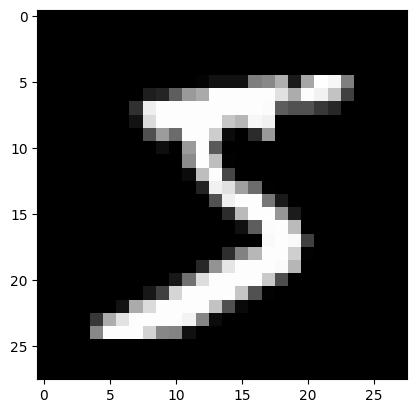

In [11]:
plt.imshow(images[0], cmap='gray')
plt.show()

In [12]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [13]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [14]:
type(images)

numpy.ndarray

In [15]:
print(images.shape)

(60000, 28, 28)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [17]:
model = Sequential([
    Conv2D(6, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2,2)),
    Conv2D(16, (5,5), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(10, activation='softmax')
])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 6)         156       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 6)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 16)          2416      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 16)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 120)               3

In [19]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [20]:
images_valid = images[55000:]
labels_valid = train_labels[55000:]

In [21]:
training = model.fit(images, train_labels, epochs=15, validation_data=(images_valid, labels_valid))

Epoch 1/15
1875/1875 [==============================] - 8s 3ms/step - loss: 0.7006 - sparse_categorical_accuracy: 0.7820 - val_loss: 0.2434 - val_sparse_categorical_accuracy: 0.9212
Epoch 2/15
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2242 - sparse_categorical_accuracy: 0.9323 - val_loss: 0.1801 - val_sparse_categorical_accuracy: 0.9420
Epoch 3/15
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1677 - sparse_categorical_accuracy: 0.9489 - val_loss: 0.1126 - val_sparse_categorical_accuracy: 0.9672
Epoch 4/15
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1306 - sparse_categorical_accuracy: 0.9602 - val_loss: 0.0811 - val_sparse_categorical_accuracy: 0.9756
Epoch 5/15
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1060 - sparse_categorical_accuracy: 0.9680 - val_loss: 0.0771 - val_sparse_categorical_accuracy: 0.9766
Epoch 6/15
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0920 - spars

In [22]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.0966 - sparse_categorical_accuracy: 0.9762


[0.09664084762334824, 0.9761999845504761]

In [23]:
test_pred = model.predict(test_images)

In [24]:
test_pred[0].shape

(10,)

In [25]:
test_pred = test_pred.argmax(axis=-1)

In [26]:
f1_class = f1_score(test_labels, test_pred,average=None)
print(f1_class)

[0.9823143  0.98947368 0.9776482  0.97403234 0.9745935  0.96855346
 0.98276762 0.97712895 0.96911392 0.96363636]


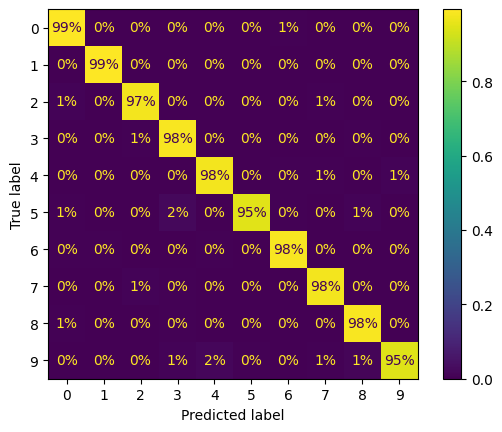

In [27]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_pred, normalize='true', values_format='.0%')